In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [48]:
data = pd.read_csv("train.csv")

In [49]:
data

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
...,...,...,...,...,...,...,...,...,...
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert


In [50]:
data.dtypes

id                             int64
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

In [51]:
data.shape

(18524, 9)

In [52]:
dupes = data[data.duplicated()]
dupes.shape

(0, 9)

In [53]:
print((data.isna().sum()/6175)*100) 

id                            0.000000
Time_spent_Alone             19.271255
Stage_fear                   30.655870
Social_event_attendance      19.109312
Going_outside                23.740891
Drained_after_socializing    18.607287
Friends_circle_size          17.068826
Post_frequency               20.469636
Personality                   0.000000
dtype: float64


In [54]:
cols = list(data.columns)

multiple_isnull = data[data[cols].isna().all(axis=1)]
multiple_isnull

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality


In [55]:
col_count = data.shape[1]

majority_is_null = data[data[cols].isna().sum(axis=1) > col_count//2]
majority_is_null

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality


Decent Data!

<Axes: xlabel='Time_spent_Alone'>

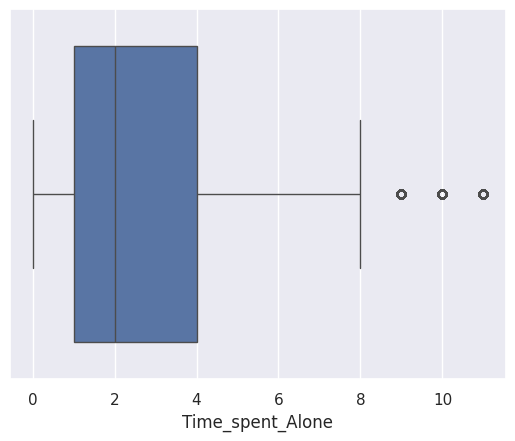

In [37]:
sns.set(color_codes=True)
sns.boxplot(x=data["Time_spent_Alone"])

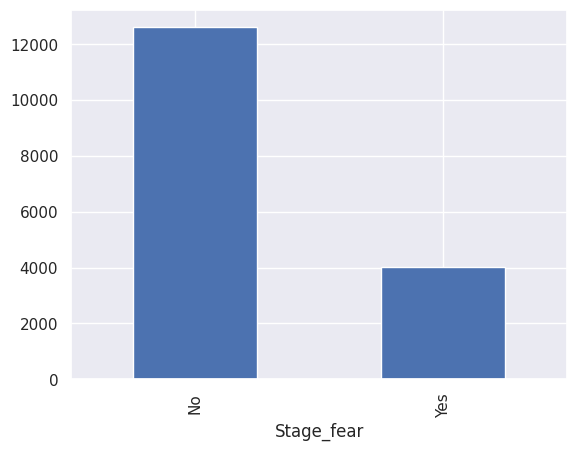

In [56]:
data["Stage_fear"].value_counts().plot(kind="bar")
plt.show()


<Axes: xlabel='Time_spent_Alone'>

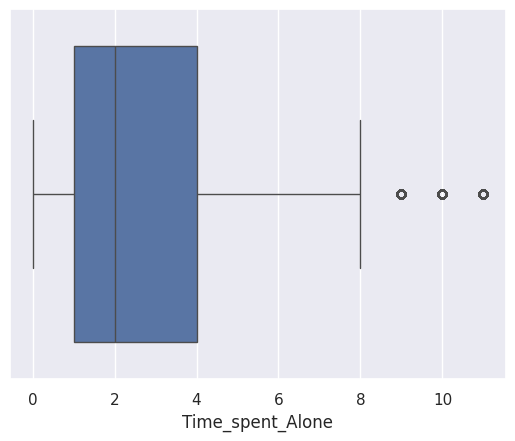

In [57]:
sns.boxplot(x=data["Time_spent_Alone"])

<Axes: xlabel='Going_outside'>

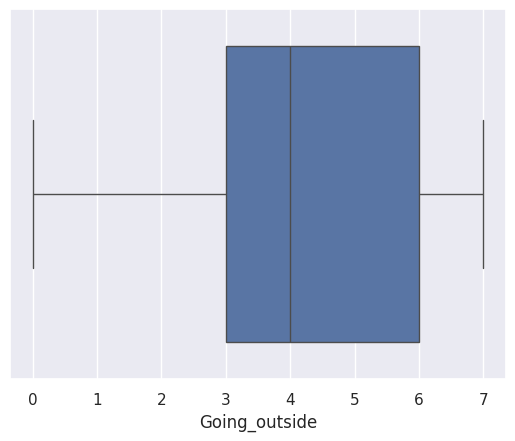

In [58]:
sns.boxplot(x=data["Going_outside"])

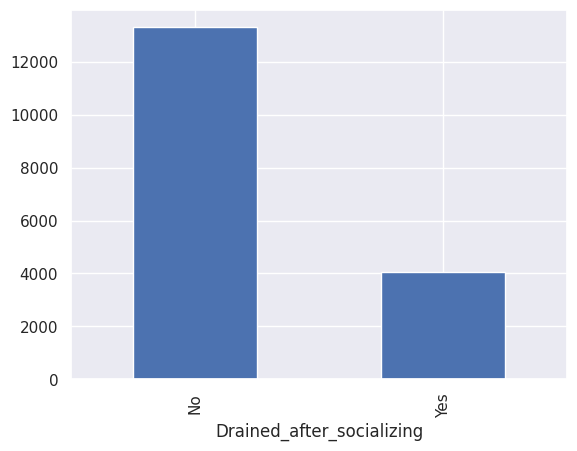

In [59]:
data["Drained_after_socializing"].value_counts().plot(kind="bar")
plt.show()

<Axes: xlabel='Friends_circle_size'>

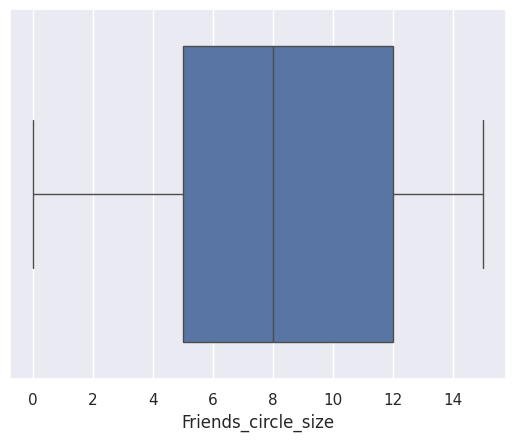

In [60]:
sns.boxplot(x=data["Friends_circle_size"])

<Axes: xlabel='Post_frequency'>

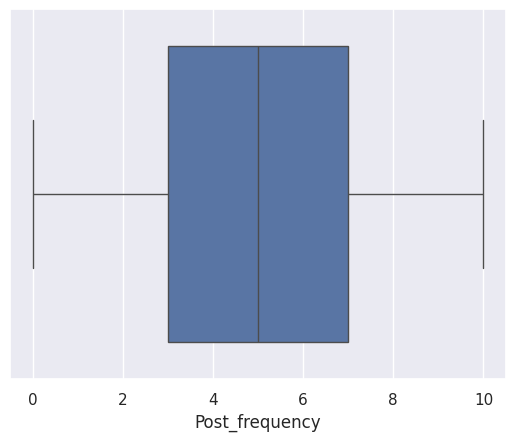

In [61]:
sns.boxplot(x=data["Post_frequency"])

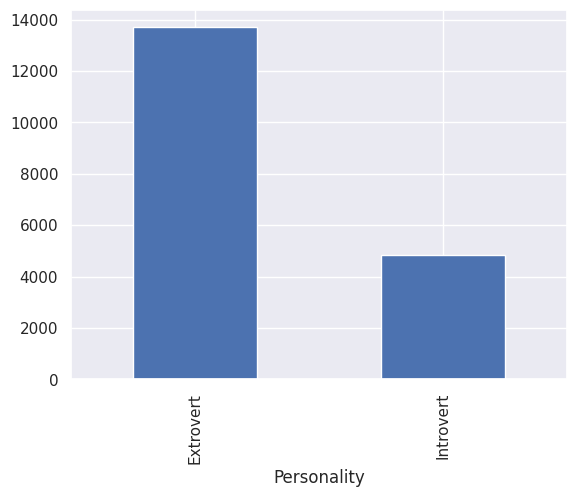

In [63]:
data["Personality"].value_counts().plot(kind="bar")
plt.show()

In [102]:
full = data[data[cols].isna().sum(axis=1) == 0]
full.head(15)

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
7,7,2.0,No,8.0,3.0,No,4.0,5.0,Extrovert
9,9,1.0,No,8.0,6.0,No,14.0,9.0,Extrovert
10,10,3.0,No,7.0,4.0,No,5.0,10.0,Extrovert
11,11,2.0,No,6.0,3.0,No,4.0,8.0,Extrovert
12,12,3.0,No,5.0,4.0,No,9.0,6.0,Extrovert
16,16,0.0,No,6.0,4.0,No,8.0,10.0,Extrovert
18,18,1.0,No,4.0,4.0,No,11.0,9.0,Extrovert


In [103]:
full = full.replace({'Yes':1,'No':0})
full["Personality"] = full["Personality"].str.strip()
full["Personality"] = full["Personality"].replace({'Extrovert':0,'Introvert':1})
full

/tmp/ipykernel_2066/1518142994.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full = full.replace({'Yes':1,'No':0})
/tmp/ipykernel_2066/1518142994.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full["Personality"] = full["Personality"].replace({'Extrovert':0,'Introvert':1})


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0,6.0,4.0,0,15.0,5.0,0
1,1,1.0,0,7.0,3.0,0,10.0,8.0,0
3,3,3.0,0,7.0,3.0,0,11.0,5.0,0
7,7,2.0,0,8.0,3.0,0,4.0,5.0,0
9,9,1.0,0,8.0,6.0,0,14.0,9.0,0
...,...,...,...,...,...,...,...,...,...
18509,18509,1.0,0,3.0,4.0,0,15.0,4.0,0
18511,18511,0.0,0,4.0,5.0,0,11.0,4.0,0
18514,18514,6.0,0,5.0,3.0,0,10.0,4.0,0
18519,18519,3.0,0,7.0,3.0,0,9.0,7.0,0


In [104]:
full.dtypes

id                             int64
Time_spent_Alone             float64
Stage_fear                     int64
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing      int64
Friends_circle_size          float64
Post_frequency               float64
Personality                    int64
dtype: object

In [105]:
Q1 = full.quantile(0.25)
Q3 = full.quantile(0.75)

IQR = Q3 - Q1
print(IQR)

id                           9225.0
Time_spent_Alone                2.0
Stage_fear                      0.0
Social_event_attendance         4.0
Going_outside                   3.0
Drained_after_socializing       0.0
Friends_circle_size             7.0
Post_frequency                  5.0
Personality                     0.0
dtype: float64


In [106]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print([lower_bound,upper_bound])

[id                          -9184.5
Time_spent_Alone               -2.0
Stage_fear                      0.0
Social_event_attendance        -2.0
Going_outside                  -1.5
Drained_after_socializing       0.0
Friends_circle_size            -5.5
Post_frequency                 -4.5
Personality                     0.0
dtype: float64, id                           27715.5
Time_spent_Alone                 6.0
Stage_fear                       0.0
Social_event_attendance         14.0
Going_outside                   10.5
Drained_after_socializing        0.0
Friends_circle_size             22.5
Post_frequency                  15.5
Personality                      0.0
dtype: float64]


In [107]:
full = full[~((full < (Q1-1.5*IQR)) | (full > (Q3+1.5*IQR))).any(axis=1)]
full.shape

(8232, 9)

In [108]:
full

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,0,6.0,4.0,0,15.0,5.0,0
1,1,1.0,0,7.0,3.0,0,10.0,8.0,0
3,3,3.0,0,7.0,3.0,0,11.0,5.0,0
7,7,2.0,0,8.0,3.0,0,4.0,5.0,0
9,9,1.0,0,8.0,6.0,0,14.0,9.0,0
...,...,...,...,...,...,...,...,...,...
18509,18509,1.0,0,3.0,4.0,0,15.0,4.0,0
18511,18511,0.0,0,4.0,5.0,0,11.0,4.0,0
18514,18514,6.0,0,5.0,3.0,0,10.0,4.0,0
18519,18519,3.0,0,7.0,3.0,0,9.0,7.0,0


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,1.000000,-0.007007,NaN,0.014815,0.006031,NaN,0.020542,0.005960,NaN
Time_spent_Alone,-0.007007,1.000000,NaN,0.043300,0.025387,NaN,0.019381,0.026068,NaN
Stage_fear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Social_event_attendance,0.014815,0.043300,NaN,1.000000,0.011012,NaN,0.065614,0.027829,NaN
Going_outside,0.006031,0.025387,NaN,0.011012,1.000000,NaN,0.002343,0.011715,NaN
Drained_after_socializing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Friends_circle_size,0.020542,0.019381,NaN,0.065614,0.002343,NaN,1.000000,0.018154,NaN
Post_frequency,0.005960,0.026068,NaN,0.027829,0.011715,NaN,0.018154,1.000000,NaN
Personality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


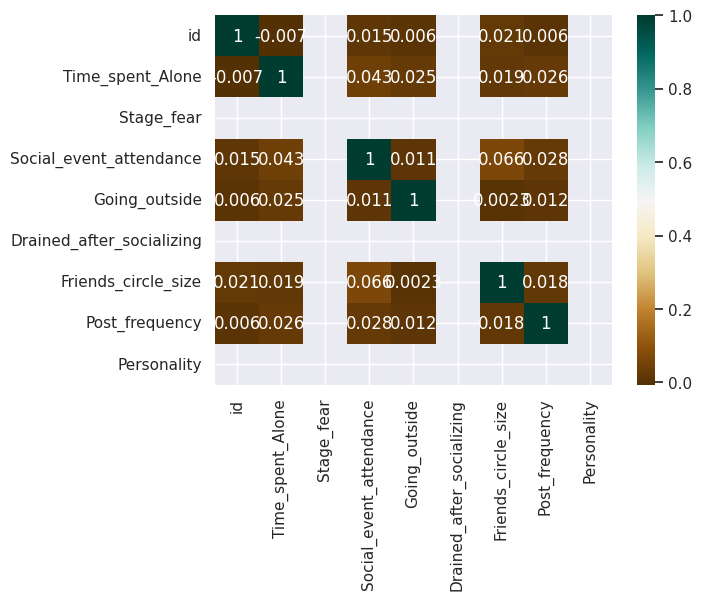

In [109]:
c = full.corr(min_periods=1)
sns.heatmap(c,cmap="BrBG",annot=True)
c

<Axes: >

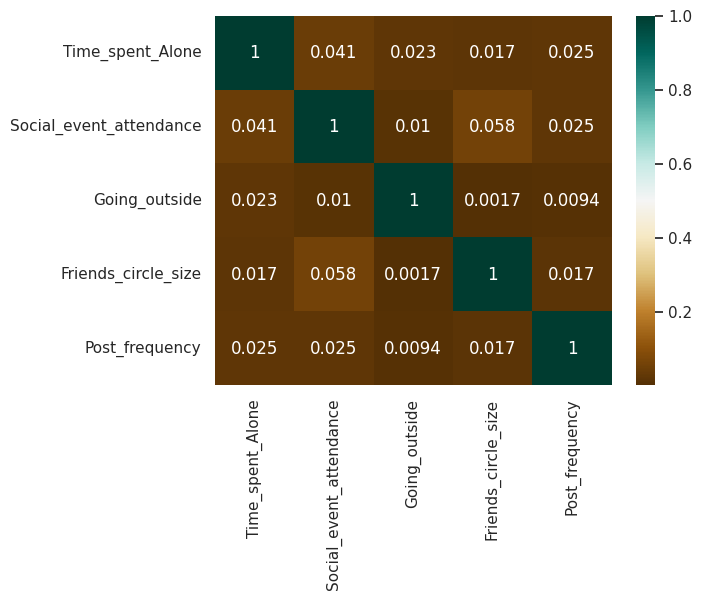

In [112]:
columns = ["Time_spent_Alone","Social_event_attendance","Going_outside","Friends_circle_size","Post_frequency"]
c = full[columns].corr(method="spearman")
sns.heatmap(c,cmap="BrBG",annot=True)

In [ ]:
import sklearn

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy = 'Median')
cat_imputer = SimpleImputer(strategy = 'most_frequent')


In [119]:
x = full.drop(columns=['Personality'])
y = full['Personality']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [120]:
num_ft = full.select_dtypes(include = ['int64','float64']).columns
cat_ft = full.select_dtypes(exclude = ['int64','float64']).columns

num_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
cat_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy = 'most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers = [('num', num_transformer,num_ft),('cat',cat_transformer,cat_ft)])

In [ ]:
models = {'Logistic Regression': LogisticRegression(max_iter=1000),
          'Decision Tree': DecisionTreeClassifier(),
          'KNN': KNeighborsClassifier()
          }